In [1]:
# ==============================
# Standard Libraries
# ==============================

import warnings
warnings.filterwarnings("ignore")

import os
import re
import string

from pathlib import Path

# ==============================
# Data Handling
# ==============================

import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================

import matplotlib.pyplot as plt

# ==============================
# Machine Learning
# ==============================

from sklearn.model_selection import train_test_split

# ==============================
# NLP
# ==============================

import nltk
import spacy

from nltk.corpus import stopwords

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))

print("spaCy Loaded Successfully")

spaCy Loaded Successfully


In [4]:
BASE_DIR = Path.cwd()

DATASET_DIR = BASE_DIR / "dataset"

In [5]:
import os

print(os.getcwd())

C:\Users\Lenovo\Resume_AI_Research\notebooks


In [6]:
import os

print(os.listdir())

['.ipynb_checkpoints', '01_Data_Loading.ipynb.ipynb', '02_Data_Preprocessing.ipynb.ipynb', '03_Feature_Engineering.ipynb.ipynb', '04_NLP_Preprocessing.ipynb.ipynb', 'best_resume_model.pkl', 'Research_Implementation.ipynb.ipynb', 'scaler.pkl', 'tfidf_vectorizer.pkl']


In [7]:
from pathlib import Path

print("Current Directory:", Path.cwd())
print("Parent Directory :", Path.cwd().parent)

Current Directory: C:\Users\Lenovo\Resume_AI_Research\notebooks
Parent Directory : C:\Users\Lenovo\Resume_AI_Research


In [8]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATASET_DIR = BASE_DIR / "dataset"

print(DATASET_DIR)

C:\Users\Lenovo\Resume_AI_Research\dataset


In [9]:
import os

print(os.listdir(DATASET_DIR))

['.ipynb_checkpoints', 'job_descriptions', 'processed', 'resumes', 'resume_data.csv', 'resume_data_for_ranking.csv']


In [10]:
resume_df = pd.read_csv(DATASET_DIR / "Resume_Data_For_Ranking.csv")

In [11]:
resume_df.shape

(9544, 35)

In [12]:
print(os.listdir(DATASET_DIR))

['.ipynb_checkpoints', 'job_descriptions', 'processed', 'resumes', 'resume_data.csv', 'resume_data_for_ranking.csv']


In [13]:
resume_df.columns = (
    resume_df.columns
    .str.strip()
    .str.lower()
)

resume_df.columns.tolist()

['address',
 'career_objective',
 'skills',
 'educational_institution_name',
 'degree_names',
 'passing_years',
 'educational_results',
 'result_types',
 'major_field_of_studies',
 'professional_company_names',
 'company_urls',
 'start_dates',
 'end_dates',
 'related_skils_in_job',
 'positions',
 'locations',
 'responsibilities',
 'extra_curricular_activity_types',
 'extra_curricular_organization_names',
 'extra_curricular_organization_links',
 'role_positions',
 'languages',
 'proficiency_levels',
 'certification_providers',
 'certification_skills',
 'online_links',
 'issue_dates',
 'expiry_dates',
 'job_position_name',
 'educational_requirements',
 'experiencere_requirement',
 'age_requirement',
 'responsibilities.1',
 'skills_required',
 'matched_score']

In [14]:
candidate_columns = [
    "career_objective",
    "skills",
    "degree_names",
    "major_field_of_studies",
    "professional_company_names",
    "positions",
    "certification_skills"
]

job_columns = [
    "job_position_name",
    "skills_required",
    "educational_requirements",
    "experiencere_requirement"
]

In [15]:
required_columns = candidate_columns + job_columns

missing = [c for c in required_columns if c not in resume_df.columns]

print(missing)

[]


In [16]:
resume_df[required_columns] = (
    resume_df[required_columns]
    .fillna("")
)

In [17]:
resume_df["candidate_profile"] = (
    resume_df[candidate_columns]
    .astype(str)
    .agg(" ".join, axis=1)
)

In [18]:
resume_df["job_profile"] = (
    resume_df[job_columns]
    .astype(str)
    .agg(" ".join, axis=1)
)

In [19]:
resume_df[
    [
        "candidate_profile",
        "job_profile",
        "matched_score"
    ]
].head()

,candidate_profile,job_profile,matched_score
0,Big data analytics working and database wareho...,Senior Software Engineer B.Sc in Computer Sci...,0.850000
1,Fresher looking to join as a data analyst and ...,Machine Learning (ML) Engineer M.Sc in Comput...,0.750000
2,"['Software Development', 'Machine Learning', ...","Executive/ Senior Executive- Trade Marketing, ...",0.416667
3,To obtain a position in a fast-paced business ...,Business Development Executive Fast typing ski...,0.760000
4,Professional accountant with an outstanding wo...,Senior iOS Engineer iOS\niOS App Developer\niO...,0.650000


In [20]:
PROCESSED_DIR = DATASET_DIR / "processed"

PROCESSED_DIR.mkdir(exist_ok=True)

resume_df.to_csv(
    PROCESSED_DIR / "profiles_created.csv",
    index=False
)

print("Profiles saved successfully.")

Profiles saved successfully.


In [21]:
import re
import string
import pandas as pd
import spacy
from nltk.corpus import stopwords

In [22]:
nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words("english"))

print("spaCy Loaded")

spaCy Loaded


In [23]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", " ", text)

    # remove emails
    text = re.sub(r"\S+@\S+", " ", text)

    # remove digits
    text = re.sub(r"\d+", " ", text)

    # remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [24]:
def preprocess_text(text):

    text = clean_text(text)

    doc = nlp(text)

    tokens = []

    for token in doc:

        if token.is_stop:
            continue

        if token.is_punct:
            continue

        if token.lemma_ == "-PRON-":
            continue

        tokens.append(token.lemma_)

    return " ".join(tokens)

In [25]:
sample = resume_df["candidate_profile"].iloc[0]

print(sample)

Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with them. Currently in search of role that offers more of development. ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure'] ['B.Tech'] ['Electronics'] ['Coca-COla'] ['Big Data Analyst'] 


In [26]:
cleaned = preprocess_text(sample)

print(cleaned)

big data analytic work database warehouse manager robust experience handle kind datum multiple cloud infrastructure service acquainted currently search role offer development big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java datum science c data structure dbms rdbms informatica talend amazon redshift microsoft azure btech electronic cocacola big data analyst


In [27]:
resume_df["candidate_clean"] = (
    resume_df["candidate_profile"]
    .apply(preprocess_text)
)

resume_df["job_clean"] = (
    resume_df["job_profile"]
    .apply(preprocess_text)
)

In [28]:
resume_df[
    [
        "candidate_clean",
        "job_clean",
        "matched_score"
    ]
].head()

,candidate_clean,job_clean,matched_score
0,big data analytic work database warehouse mana...,senior software engineer bsc computer science ...,0.850000
1,fresher look join data analyst junior datum sc...,machine learning ml engineer msc computer scie...,0.750000
2,software development machine learn deep learn ...,executive senior executive trade marketing hyg...,0.416667
3,obtain position fastpaced business office envi...,business development executive fast type skill...,0.760000
4,professional accountant outstanding work ethic...,senior io engineer ios ios app developer ios a...,0.650000


In [29]:
resume_df.to_csv(
    DATASET_DIR / "processed" / "cleaned_profiles.csv",
    index=False
)

print("✅ Cleaned dataset saved successfully.")

✅ Cleaned dataset saved successfully.


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [31]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

In [32]:
combined_text = pd.concat([
    resume_df["candidate_clean"],
    resume_df["job_clean"]
])

tfidf.fit(combined_text)

print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 5000


In [33]:
candidate_vectors = tfidf.transform(
    resume_df["candidate_clean"]
)

In [34]:
job_vectors = tfidf.transform(
    resume_df["job_clean"]
)

In [35]:
tfidf_similarity = []

for i in range(len(resume_df)):
    
    score = cosine_similarity(
        candidate_vectors[i],
        job_vectors[i]
    )[0][0]
    
    tfidf_similarity.append(score)

resume_df["tfidf_similarity"] = tfidf_similarity

In [36]:
resume_df[
    [
        "tfidf_similarity",
        "matched_score"
    ]
].head()

,tfidf_similarity,matched_score
0,0.004925,0.850000
1,0.039016,0.750000
2,0.000000,0.416667
3,0.004840,0.760000
4,0.005924,0.650000


In [37]:
resume_df["tfidf_similarity"].describe()

count    9544.000000
mean        0.017112
std         0.024408
min         0.000000
25%         0.000000
50%         0.008448
75%         0.023281
max         0.273923
Name: tfidf_similarity, dtype: float64

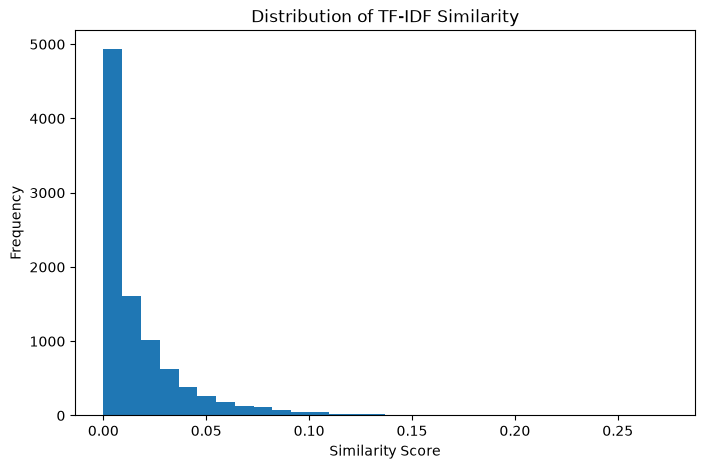

In [38]:
plt.figure(figsize=(8,5))

plt.hist(
    resume_df["tfidf_similarity"],
    bins=30
)

plt.title("Distribution of TF-IDF Similarity")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.show()

In [39]:
resume_df.to_csv(
    DATASET_DIR / "processed" / "tfidf_features.csv",
    index=False
)

print("✅ TF-IDF features saved successfully.")

✅ TF-IDF features saved successfully.


In [40]:
!pip install sentence-transformers

In [41]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [42]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Sentence-BERT Loaded")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7357.93it/s]


Sentence-BERT Loaded


In [47]:
candidate_embeddings = model.encode(
    resume_df["candidate_clean"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches: 100%|██████████| 299/299 [01:15<00:00,  3.95it/s]


In [48]:
print("candidate_embeddings" in globals())
print("job_embeddings" in globals())

True
False


In [51]:
print(candidate_embeddings.shape)

(9544, 384)


In [52]:
job_embeddings = model.encode(
    resume_df["job_clean"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches: 100%|██████████| 299/299 [00:22<00:00, 13.41it/s]


In [53]:
print(job_embeddings.shape)

(9544, 384)


In [54]:
from sklearn.metrics.pairwise import paired_cosine_distances

resume_df["semantic_similarity"] = (
    1 - paired_cosine_distances(
        candidate_embeddings,
        job_embeddings
    )
)

resume_df["semantic_similarity"].head()

0    0.273521
1    0.406173
2    0.201202
3    0.547940
4    0.235086
Name: semantic_similarity, dtype: float32

In [55]:
resume_df["semantic_similarity"].describe()

count    9544.000000
mean        0.315485
std         0.118139
min        -0.048101
25%         0.233929
50%         0.314727
75%         0.396875
max         0.737107
Name: semantic_similarity, dtype: float64

In [57]:
semantic_similarity = []

for i in range(len(resume_df)):
    score = cosine_similarity(
        candidate_embeddings[i].reshape(1, -1),
        job_embeddings[i].reshape(1, -1)
    )[0][0]

    semantic_similarity.append(score)

resume_df["semantic_similarity"] = semantic_similarity

In [58]:
candidate_embeddings.shape

(9544, 384)

In [59]:
job_embeddings = model.encode(
    resume_df["job_clean"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches: 100%|██████████| 299/299 [00:22<00:00, 13.36it/s]


In [60]:
job_embeddings.shape

(9544, 384)

In [61]:
from sklearn.metrics.pairwise import paired_cosine_distances

resume_df["semantic_similarity"] = (
    1 - paired_cosine_distances(
        candidate_embeddings,
        job_embeddings
    )
)

In [62]:
from sklearn.metrics.pairwise import paired_cosine_distances

resume_df["semantic_similarity"] = (
    1 - paired_cosine_distances(
        candidate_embeddings,
        job_embeddings
    )
)

In [63]:
resume_df["semantic_similarity"].head()

0    0.273521
1    0.406173
2    0.201202
3    0.547940
4    0.235086
Name: semantic_similarity, dtype: float32

In [64]:
candidate_embeddings.shape

(9544, 384)

In [65]:
job_embeddings.shape

(9544, 384)

In [66]:
def extract_skills(skill_text):

    if pd.isna(skill_text):
        return set()

    skill_text = str(skill_text).lower()

    skill_text = skill_text.replace("[", "")
    skill_text = skill_text.replace("]", "")
    skill_text = skill_text.replace("'", "")

    skills = [
        s.strip()
        for s in skill_text.split(",")
        if s.strip()
    ]

    return set(skills)

In [67]:
skill_scores = []

for _, row in resume_df.iterrows():

    candidate = extract_skills(row["skills"])

    required = extract_skills(row["skills_required"])

    if len(required) == 0:
        score = 0

    else:
        score = len(candidate & required) / len(required)

    skill_scores.append(score)

resume_df["skill_match_score"] = skill_scores

In [68]:
resume_df[
    [
        "skills",
        "skills_required",
        "skill_match_score"
    ]
].head()

,skills,skills_required,skill_match_score
0,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",,0.0
1,"['Data Analysis', 'Data Analytics', 'Business ...",,0.0
2,"['Software Development', 'Machine Learning', '...",Brand Promotion\nCampaign Management\nField Su...,0.0
3,"['accounts payables', 'accounts receivables', ...",Fast typing skill\nIELTSInternet browsing & on...,0.0
4,"['Analytical reasoning', 'Compliance testing k...",iOS\niOS App Developer\niOS Application Develo...,0.0


In [69]:
education_rank = {
    "high school": 1,
    "diploma": 2,
    "b.sc": 3,
    "b.tech": 3,
    "b.e": 3,
    "bachelor": 3,
    "m.sc": 4,
    "m.tech": 4,
    "mba": 4,
    "master": 4,
    "phd": 5,
    "doctorate": 5
}

In [70]:
def education_score(candidate, required):

    candidate = str(candidate).lower()
    required = str(required).lower()

    candidate_level = 0
    required_level = 0

    for degree, level in education_rank.items():

        if degree in candidate:
            candidate_level = max(candidate_level, level)

        if degree in required:
            required_level = max(required_level, level)

    if required_level == 0:
        return 0.5

    if candidate_level >= required_level:
        return 1.0

    return candidate_level / required_level

In [71]:
resume_df["education_match_score"] = resume_df.apply(
    lambda row: education_score(
        row["degree_names"],
        row["educational_requirements"]
    ),
    axis=1
)

In [72]:
resume_df[
    [
        "degree_names",
        "educational_requirements",
        "education_match_score"
    ]
].head()

,degree_names,educational_requirements,education_match_score
0,['B.Tech'],B.Sc in Computer Science & Engineering from a ...,1.00
1,"['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']",M.Sc in Computer Science & Engineering or in a...,1.00
2,['B.Tech'],Master of Business Administration (MBA),0.75
3,['Computer Applications Specialist Certificate...,Bachelor/Honors,0.00
4,['Bachelor of Business Administration'],Bachelor of Science (BSc) in Computer Science,1.00


In [73]:
import re

def extract_years(text):

    text = str(text)

    numbers = re.findall(r"\d+", text)

    if len(numbers) == 0:
        return 0

    return int(numbers[0])

In [74]:
def experience_score(candidate, required):

    c = extract_years(candidate)
    r = extract_years(required)

    if r == 0:
        return 0.5

    if c >= r:
        return 1.0

    return c / r

In [75]:
resume_df["experience_match_score"] = resume_df.apply(
    lambda row: experience_score(
        row["positions"],
        row["experiencere_requirement"]
    ),
    axis=1
)

In [76]:
resume_df[
    [
        "positions",
        "experiencere_requirement",
        "experience_match_score"
    ]
].head()

,positions,experiencere_requirement,experience_match_score
0,['Big Data Analyst'],At least 1 year,0.0
1,['Business Analyst'],At least 5 year(s),0.0
2,['Software Developer (Machine Learning Enginee...,At least 3 years,0.0
3,"['Accountant', 'Accounts Receivable Clerk', 'M...",1 to 3 years,0.0
4,"['Staff Accountant', 'Senior Accountant', 'Tax...",At least 4 years,0.0


In [77]:
def certification_score(candidate, required):

    candidate = set(
        str(candidate).lower().split(",")
    )

    required = set(
        str(required).lower().split(",")
    )

    candidate = {x.strip() for x in candidate if x.strip()}
    required = {x.strip() for x in required if x.strip()}

    if len(required) == 0:
        return 0.5

    return len(candidate & required) / len(required)

In [78]:
resume_df["certification_match_score"] = resume_df.apply(
    lambda row: certification_score(
        row["certification_skills"],
        row["skills_required"]
    ),
    axis=1
)

In [79]:
resume_df[
    [
        "certification_skills",
        "skills_required",
        "certification_match_score"
    ]
].head()

,certification_skills,skills_required,certification_match_score
0,,,0.5
1,,,0.5
2,,Brand Promotion\nCampaign Management\nField Su...,0.0
3,,Fast typing skill\nIELTSInternet browsing & on...,0.0
4,[None],iOS\niOS App Developer\niOS Application Develo...,0.0


In [80]:
features = [
    "tfidf_similarity",
    "semantic_similarity",
    "skill_match_score",
    "education_match_score",
    "experience_match_score",
    "certification_match_score"
]

X = resume_df[features]

y = resume_df["matched_score"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (9544, 6)
Target Shape : (9544,)


In [81]:
X.shape

(9544, 6)

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7635, 6)
(1909, 6)


In [83]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [84]:
y_pred = lr.predict(X_test)

In [85]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse**0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.12421202984263274
RMSE: 0.15696305509805347
R²  : 0.10906418586905675


In [86]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [87]:
rf_pred = rf.predict(
    X_test
)

In [88]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")

print("MAE :", rf_mae)

print("RMSE:", rf_rmse)

print("R² :", rf_r2)

Random Forest
MAE : 0.1295619888978942
RMSE: 0.1666630178749059
R² : -0.004453911098123653


In [89]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest"

    ],

    "MAE":[

        mae,

        rf_mae

    ],

    "RMSE":[

        rmse,

        rf_rmse

    ],

    "R2":[

        r2,

        rf_r2

    ]

})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.124212,0.156963,0.109064
1,Random Forest,0.129562,0.166663,-0.004454


In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [91]:
!pip install shap

In [92]:
import shap
import matplotlib.pyplot as plt

In [93]:
explainer = shap.Explainer(lr, X_train)

In [94]:
shap_values = explainer(X_test)

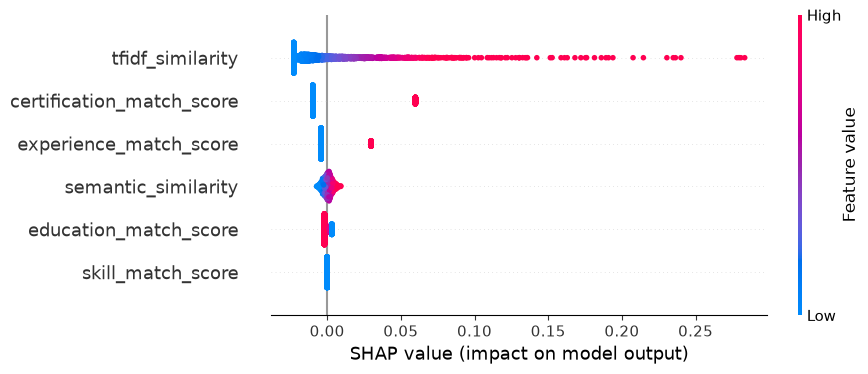

In [95]:
shap.plots.beeswarm(shap_values)

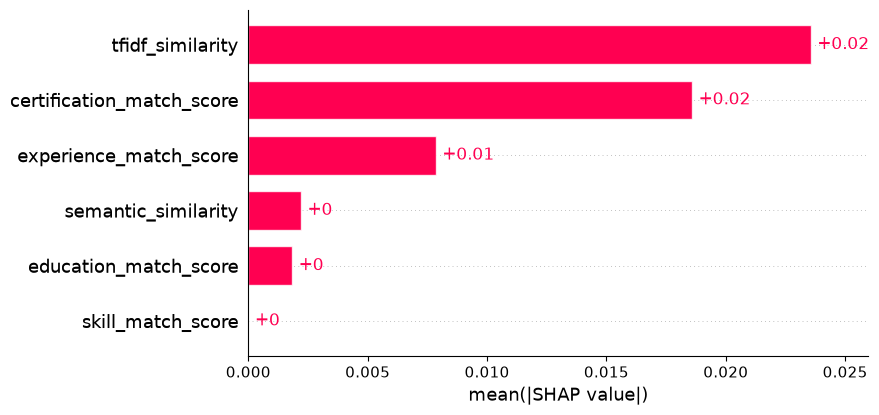

In [96]:
shap.plots.bar(shap_values)

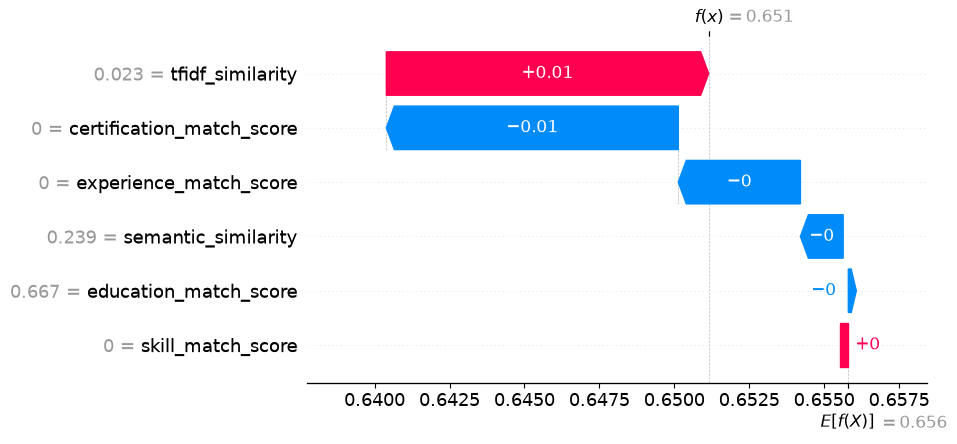

In [97]:
shap.plots.waterfall(shap_values[0])

In [98]:
from pathlib import Path

BASE_DIR = Path.cwd().parent   # because notebook is inside notebooks/

FIGURES_DIR = BASE_DIR / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

print(FIGURES_DIR)

C:\Users\Lenovo\Resume_AI_Research\figures


In [99]:
plt.savefig(
    FIGURES_DIR / "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

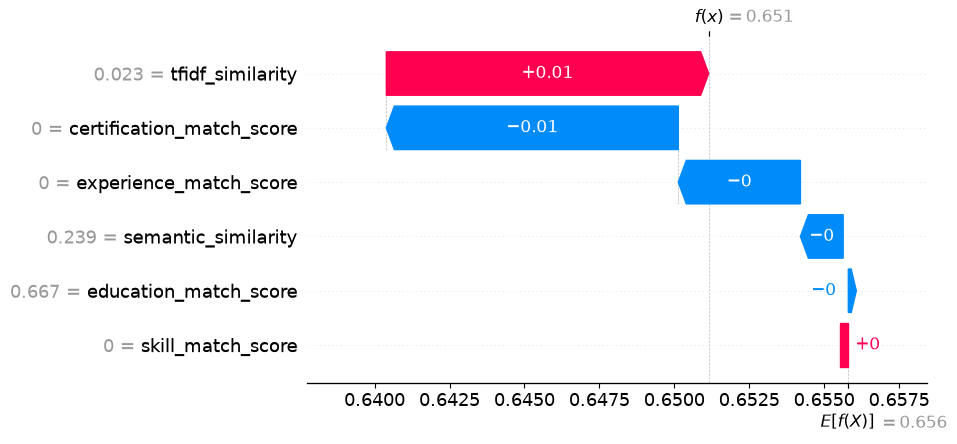

In [100]:
sample_index = 0

shap.plots.waterfall(
    shap_values[sample_index]
)

In [101]:
plt.savefig(
    DATASET_DIR / "processed" / "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [102]:
resume_df["predicted_score"] = lr.predict(X)

In [103]:
ranking = resume_df[
    [
        "job_position_name",
        "predicted_score"
    ]
].sort_values(
    by="predicted_score",
    ascending=False
)

ranking.head(10)

,job_position_name,predicted_score
374,Mechanical Engineer,1.023168
5982,Senior Software Engineer,1.001821
4538,Senior Software Engineer,0.979033
6587,Management Trainee - Mechanical,0.966645
5059,Data Engineer,0.957018
2281,Data Engineer,0.952696
5399,Executive/ Sr. Executive -IT,0.948490
2380,Senior Software Engineer,0.942585
7535,Management Trainee - Mechanical,0.940089
6676,Mechanical Engineer,0.937355


In [104]:
ranking.to_csv(
    DATASET_DIR / "processed" / "candidate_ranking.csv",
    index=False
)

print("Ranking saved successfully.")

Ranking saved successfully.


In [105]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance

,Feature,Coefficient
0,tfidf_similarity,1.461640
5,certification_match_score,0.139160
2,skill_match_score,0.116065
4,experience_match_score,0.067919
1,semantic_similarity,0.022782
3,education_match_score,-0.005036


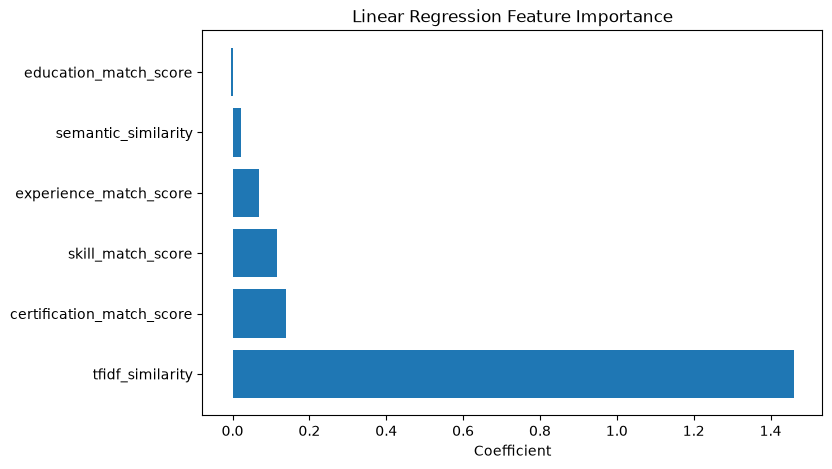

In [106]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Coefficient"]
)

plt.xlabel("Coefficient")

plt.title("Linear Regression Feature Importance")

plt.show()

In [107]:
resume_df["resume_length"] = (
    resume_df["candidate_clean"]
    .str.len()
)

In [108]:
resume_df["job_length"] = (
    resume_df["job_clean"]
    .str.len()
)

In [109]:
resume_df["resume_word_count"] = (
    resume_df["candidate_clean"]
    .str.split()
    .str.len()
)

In [110]:
resume_df["job_word_count"] = (
    resume_df["job_clean"]
    .str.split()
    .str.len()
)

In [111]:
resume_df["candidate_skill_count"] = (
    resume_df["skills"]
    .fillna("")
    .apply(lambda x: len(extract_skills(x)))
)

In [112]:
resume_df["required_skill_count"] = (
    resume_df["skills_required"]
    .fillna("")
    .apply(lambda x: len(extract_skills(x)))
)

In [113]:
def skill_overlap(candidate, required):
    candidate = extract_skills(candidate)
    required = extract_skills(required)
    return len(candidate & required)

resume_df["skill_overlap_count"] = resume_df.apply(
    lambda row: skill_overlap(
        row["skills"],
        row["skills_required"]
    ),
    axis=1
)

In [114]:
resume_df["education_exact_match"] = resume_df.apply(
    lambda row: int(
        str(row["degree_names"]).lower()
        in str(row["educational_requirements"]).lower()
    ),
    axis=1
)

In [115]:
new_features = [
    "resume_length",
    "job_length",
    "resume_word_count",
    "job_word_count",
    "candidate_skill_count",
    "required_skill_count",
    "skill_overlap_count",
    "education_exact_match"
]

resume_df[new_features].head()

,resume_length,job_length,resume_word_count,job_word_count,candidate_skill_count,required_skill_count,skill_overlap_count,education_exact_match
0,402,81,56,10,21,0,0,0
1,323,105,42,13,10,0,0,0
2,241,201,30,23,14,1,0,0
3,833,106,104,13,36,1,0,0
4,756,181,89,28,32,1,0,0


In [116]:
features = [
    "tfidf_similarity",
    "semantic_similarity",
    "skill_match_score",
    "education_match_score",
    "experience_match_score",
    "certification_match_score",
    "resume_length",
    "job_length",
    "resume_word_count",
    "job_word_count",
    "candidate_skill_count",
    "required_skill_count",
    "skill_overlap_count",
    "education_exact_match"
]

X = resume_df[features]
y = resume_df["matched_score"]

print(X.shape)

(9544, 14)


In [117]:
X.shape

(9544, 14)

In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(9544, 14)


In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7635, 14)
(1909, 14)


In [120]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [121]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = mean_squared_error(
        y_test,
        pred
    ) ** 0.5

    r2 = r2_score(y_test, pred)

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

In [122]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

comparison = comparison.sort_values(
    by="R2",
    ascending=False
)

comparison

,Model,MAE,RMSE,R2
3,Random Forest,0.091117,0.119998,0.479287
4,Gradient Boosting,0.095757,0.123852,0.445300
0,Linear Regression,0.118813,0.151134,0.174005
1,Ridge Regression,0.118817,0.151143,0.173905
2,Lasso Regression,0.119170,0.151734,0.167442


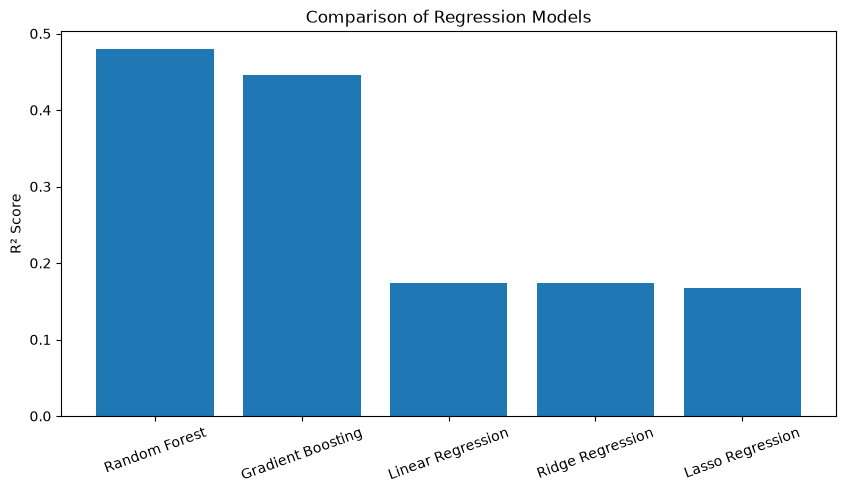

In [123]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.xticks(rotation=20)

plt.ylabel("R² Score")

plt.title("Comparison of Regression Models")

plt.show()

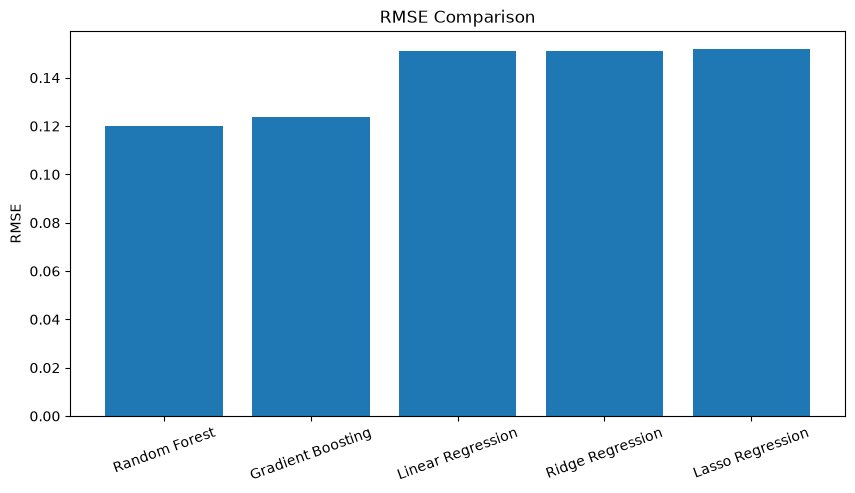

In [124]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.xticks(rotation=20)

plt.ylabel("RMSE")

plt.title("RMSE Comparison")

plt.show()

In [125]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [126]:
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [127]:
print(best_model_name)

Random Forest


In [128]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [129]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [130]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_ex

In [131]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}


In [132]:
best_rf = grid_search.best_estimator_

In [133]:
pred = best_rf.predict(X_test)

In [134]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R²  :", r2_score(y_test, pred))

MAE : 0.09071719121003846
RMSE: 0.11943142005322309
R²  : 0.4841912284746527


In [135]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

In [136]:
feature_names = X.columns.tolist()

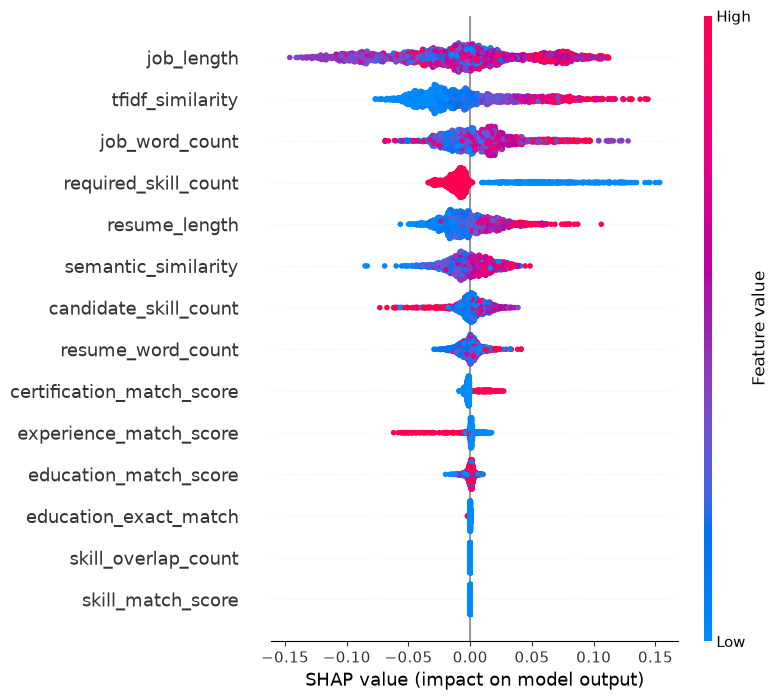

In [137]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names
)

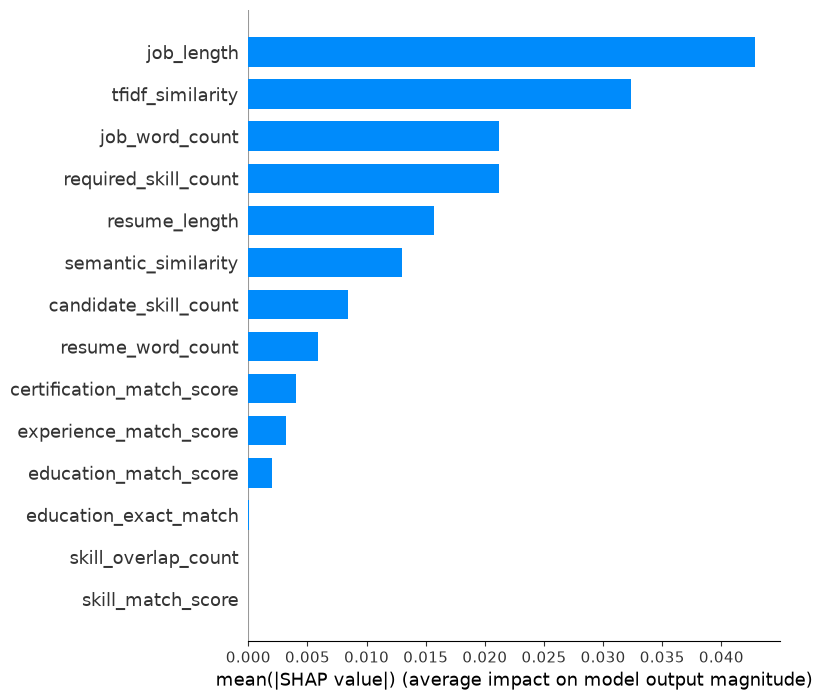

In [138]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar"
)

In [139]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,job_length,0.203154
0,tfidf_similarity,0.164234
1,semantic_similarity,0.158411
6,resume_length,0.120048
9,job_word_count,0.106545
10,candidate_skill_count,0.095608
8,resume_word_count,0.070070
11,required_skill_count,0.036932
3,education_match_score,0.019828
4,experience_match_score,0.016749


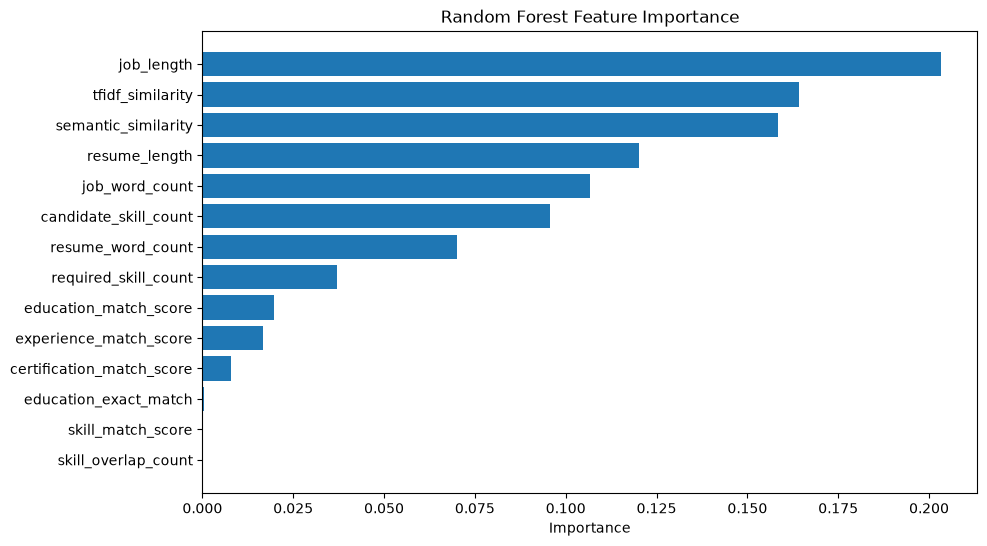

In [140]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.show()

In [141]:
import joblib

joblib.dump(
    best_rf,
    DATASET_DIR / "processed" / "best_resume_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


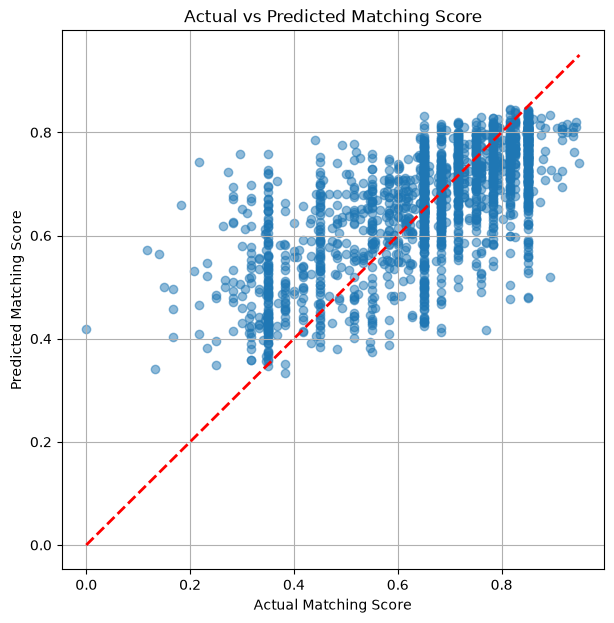

In [142]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Matching Score")
plt.ylabel("Predicted Matching Score")
plt.title("Actual vs Predicted Matching Score")

plt.grid(True)
plt.show()

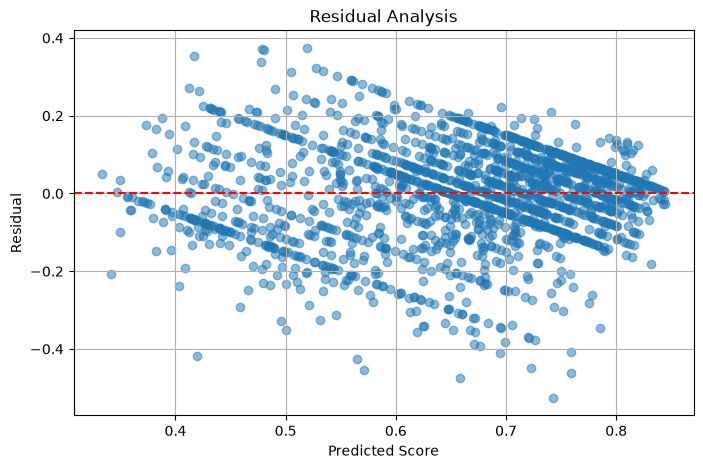

In [143]:
residuals = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, residuals, alpha=0.5)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Score")
plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.grid(True)
plt.show()

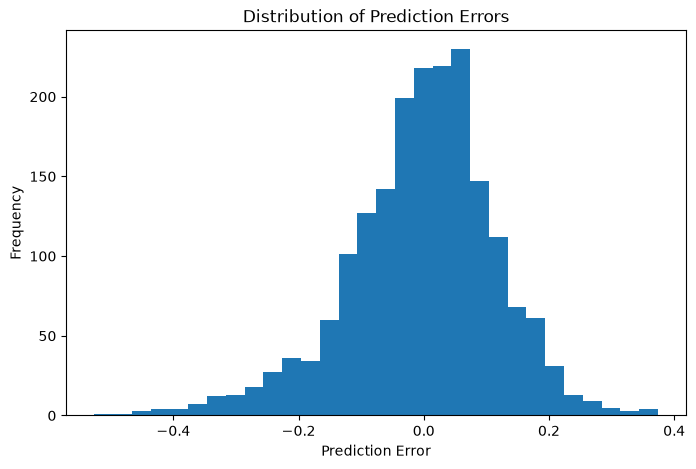

In [144]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("Distribution of Prediction Errors")

plt.show()

In [145]:
resume_df["predicted_score"] = best_rf.predict(X_scaled)

In [146]:
ranking = resume_df[
    [
        "job_position_name",
        "matched_score",
        "predicted_score"
    ]
].sort_values(
    by="predicted_score",
    ascending=False
)

ranking.head(20)

,job_position_name,matched_score,predicted_score
341,Asst. Manager/ Manger (Administrative),0.950000,0.867359
2347,Database Administrator (DBA),0.906667,0.864972
7226,HR Officer,0.883333,0.862565
6495,Manager- Human Resource Management (HRM)\n,0.850000,0.862198
5617,"Full Stack Developer (Python,React js)",0.940000,0.861061
6404,Sr.Officer / Executive - Internal Audit,0.883333,0.860146
5380,System Administrator (Operation & Maintenance ...,0.883333,0.858042
8367,Manager- Human Resource Management (HRM)\n,0.850000,0.857083
7154,Asst. Manager/ Manger (Administrative),0.896667,0.856643
2412,Manager- Human Resource Management (HRM)\n,0.893333,0.854668


In [147]:
ranking.to_csv(
    DATASET_DIR / "processed" / "final_candidate_ranking.csv",
    index=False
)

print("Ranking saved successfully.")

Ranking saved successfully.


In [148]:
resume_df.to_csv(
    DATASET_DIR / "processed" / "final_dataset_with_features.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [149]:
resume_df.to_csv(
    DATASET_DIR / "processed" / "final_dataset_with_features.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [150]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [
        mean_absolute_error(y_test, pred),
        mean_squared_error(y_test, pred) ** 0.5,
        r2_score(y_test, pred)
    ]
})

metrics

,Metric,Value
0,MAE,0.090717
1,RMSE,0.119431
2,R2,0.484191


In [151]:
metrics.to_csv(
    DATASET_DIR / "processed" / "evaluation_metrics.csv",
    index=False
)

In [152]:
import joblib

joblib.dump(best_rf, "best_resume_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [153]:
import joblib

joblib.dump(best_rf, "../models/best_resume_model.pkl")

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

print("Models Saved Successfully")

Models Saved Successfully


In [154]:
print(X.columns.tolist())

['tfidf_similarity', 'semantic_similarity', 'skill_match_score', 'education_match_score', 'experience_match_score', 'certification_match_score', 'resume_length', 'job_length', 'resume_word_count', 'job_word_count', 'candidate_skill_count', 'required_skill_count', 'skill_overlap_count', 'education_exact_match']
